In [1]:
import numpy as np
import znnl as nl

import pandas as pd

from flax import linen as nn
import optax

import matplotlib.pyplot as plt
from neural_tangents import stax

import h5py as hf
from scipy.stats import pearsonr

from rich.progress import track

import seaborn as sns

Using backend: cpu

Available hardware:

TFRT_CPU_0

## Download the data

In [2]:
generator = nl.data.MNISTGenerator(ds_size=500)

In [13]:
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 0.9, 1.0, 1.1]
ensembles = 5

data = {item: [] for item in alphas}

for item in alphas:
    for _ in range(ensembles):
        network = stax.serial(
            stax.Flatten(),
            stax.Dense(128),
            stax.Relu(),
            stax.Dense(128),
            stax.Relu(),
            stax.Dense(1),
        )

        optimizer = nl.optimizers.TraceOptimizer(
            scale_factor=item, subset=0.1, 
        )

        model = nl.models.NTModel(
                nt_module=network,
                optimizer=optimizer,
                input_shape=(1, 28, 28, 1),
        )
        training_strategy = nl.training_strategies.SimpleTraining(
            model=model, 
            loss_fn=nl.loss_functions.MeanPowerLoss(order=2),
        )
        data[item].append(
            training_strategy.train_model(
                train_ds=generator.train_ds,
                test_ds=generator.test_ds, 
                epochs=50, 
                batch_size=128
            )["train_losses"]
        )

Epoch: 50: 100%|███████████████████████████████| 50/50 [00:05<00:00,  9.86batch/s, test_loss=0.0952]


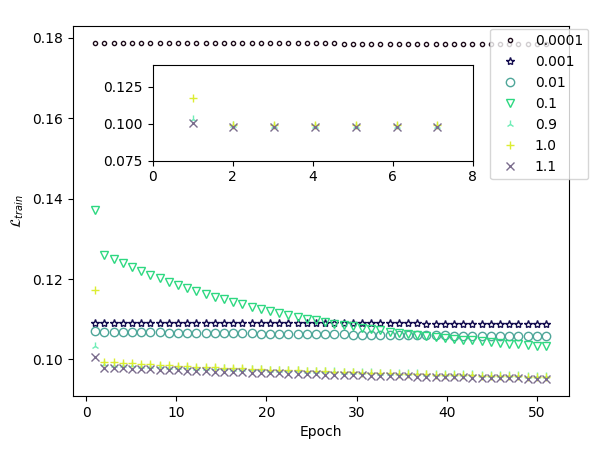

In [16]:
x_data = np.linspace(1, 51, 50)

marker_list = [".", "*", "o", "v", "2", "+", "x"]
color = [
    "#1C0B19", "#140D4F", "#4EA699", "#2DD881", "#6FEDB7", "#DCED31", "#7B6D8D"
]


fig, ax1 = plt.subplots()

# These are in unitless percentages of the figure size. (0,0 is bottom left)
left, bottom, width, height = [0.25, 0.6, 0.5, 0.2]
ax2 = fig.add_axes([left, bottom, width, height])


for i, item in enumerate(data):
    ax1.errorbar(
        x_data, 
        np.mean(data[item], axis=0),
#         yerr = np.std(data[item], axis=0),
        marker=marker_list[i],
        mfc="none",
        c=color[i],
        linestyle="none",
        label=item
    )
    if item in [0.9, 1.0, 1.1]:
        ax2.errorbar(
            x_data, 
            np.mean(data[item], axis=0),
#             yerr = np.std(data[item], axis=0),
            marker=marker_list[i],
            mfc="none",
            c=color[i],
            linestyle="none",
        )
    
    
ax2.set_xlim(0, 8)
ax2.set_ylim(0.075, 0.14)

ax1.set_xlabel("Epoch")
ax1.set_ylabel(r"$\mathcal{L}_{train}$")
fig.legend(loc=(.8, .6))
plt.savefig("mnist-alpha-opt.pdf")
plt.show()